<a href="https://colab.research.google.com/github/himanshira/Machine-Learning/blob/main/Ad_Targeting_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ad Targeting Optimization: Problem Statement
This document provides a structured approach for navigating the Ad Targeting Optimization case study, which focuses on leveraging Unsupervised Machine Learning and Deep Learning to segment users for improved ad performance.
The core challenge of this case study is to transition from a generic advertising strategy to a segmented, data-driven targeting system. Using unsupervised techniques, the objective is to analyze user demographic and behavioral data to discover latent groups (clusters) that exhibit similar characteristics and, crucially, different ad-clicking behaviors. The insights derived from these clusters will be used to recommend optimized ad budget allocation.

### Import Libraries and Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv('/../Ad Targeting Optimization/ad_click_dataset.txt')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                10000 non-null  int64  
 1   full_name         10000 non-null  object 
 2   age               5234 non-null   float64
 3   gender            5307 non-null   object 
 4   device_type       8000 non-null   object 
 5   ad_position       8000 non-null   object 
 6   browsing_history  5218 non-null   object 
 7   time_of_day       8000 non-null   object 
 8   click             10000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


In [ ]:
data.head()

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,670,User670,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,3044,User3044,NaN,Male,Desktop,Top,NaN,NaN,1
2,5912,User5912,41.0,Non-Binary,NaN,Side,Education,Night,1
3,5418,User5418,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,9452,User9452,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


# TASK 1 — Data Preprocessing

In [ ]:
# Remove Useless Columns (4.1)

data_1 = data.drop(columns=['full_name', 'id'], axis=1)
data_1.head()

,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,22.0,NaN,Desktop,Top,Shopping,Afternoon,1
1,NaN,Male,Desktop,Top,NaN,NaN,1
2,41.0,Non-Binary,NaN,Side,Education,Night,1
3,34.0,Male,NaN,NaN,Entertainment,Evening,1
4,39.0,Non-Binary,NaN,NaN,Social Media,Morning,0


# Handle Missing Values

In [ ]:
from pandas._libs import missing

# Calculate missing value percentage

missing_percentage = (data_1.isnull().sum() / len(data_1)) * 100
print("******************************")
print(f"Missing Value Percentage is:\n")
print("******************************")
missing_percentage

******************************
Missing Value Percentage is:

******************************


,0
age,47.66
gender,46.93
device_type,20.00
ad_position,20.00
browsing_history,47.82
time_of_day,20.00
click,0.00


In [ ]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               5234 non-null   float64
 1   gender            5307 non-null   object 
 2   device_type       8000 non-null   object 
 3   ad_position       8000 non-null   object 
 4   browsing_history  5218 non-null   object 
 5   time_of_day       8000 non-null   object 
 6   click             10000 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [ ]:
data_1['age'] = data_1['age'].astype('Int64')
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               5234 non-null   Int64 
 1   gender            5307 non-null   object
 2   device_type       8000 non-null   object
 3   ad_position       8000 non-null   object
 4   browsing_history  5218 non-null   object
 5   time_of_day       8000 non-null   object
 6   click             10000 non-null  int64 
dtypes: Int64(1), int64(1), object(5)
memory usage: 556.8+ KB


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pandas as pd

# 1. Define feature groups
# High missingness - fill with "Unknown"
cat_high_missing = ['gender', 'browsing_history']

# Moderate missingness - fill with Mode (most frequent)
cat_mod_missing = ['device_type', 'ad_position', 'time_of_day']

# Numerical - fill with constant and add indicator
num_features = ['age']

# 2. Create the unified preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # Strategy: Constant "Unknown"
        ('cat_unk', SimpleImputer(strategy='constant', fill_value='Unknown'), cat_high_missing),

        # Strategy: Most Frequent (Mode)
        ('cat_mode', SimpleImputer(strategy='most_frequent'), cat_mod_missing),

        # Strategy: Constant -1 + Missing Indicator
        ('num', SimpleImputer(strategy='constant', fill_value=-1, add_indicator=True), num_features)
    ],
    remainder='passthrough' # This will catch 'click' if it's in your X
)

# 3. Apply and convert to DataFrame
# Using the set_config trick so it stays a DataFrame automatically
from sklearn import set_config
set_config(transform_output="pandas")

df_processed = preprocessor.fit_transform(data_1)

In [ ]:
new_columns_name = preprocessor.get_feature_names_out()

df = pd.DataFrame(df_processed, columns=new_columns_name, index=data_1.index)
df.head()

,cat_unk__gender,cat_unk__browsing_history,cat_mode__device_type,cat_mode__ad_position,cat_mode__time_of_day,num__age,num__missingindicator_age,remainder__click
0,Unknown,Shopping,Desktop,Top,Afternoon,22.0,0.0,1
1,Male,Unknown,Desktop,Top,Morning,-1.0,1.0,1
2,Non-Binary,Education,Desktop,Side,Night,41.0,0.0,1
3,Male,Entertainment,Desktop,Bottom,Evening,34.0,0.0,1
4,Non-Binary,Social Media,Desktop,Bottom,Morning,39.0,0.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cat_unk__gender            10000 non-null  object 
 1   cat_unk__browsing_history  10000 non-null  object 
 2   cat_mode__device_type      10000 non-null  object 
 3   cat_mode__ad_position      10000 non-null  object 
 4   cat_mode__time_of_day      10000 non-null  object 
 5   num__age                   10000 non-null  float64
 6   num__missingindicator_age  10000 non-null  float64
 7   remainder__click           10000 non-null  int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 625.1+ KB


In [ ]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               5234 non-null   Int64 
 1   gender            5307 non-null   object
 2   device_type       8000 non-null   object
 3   ad_position       8000 non-null   object
 4   browsing_history  5218 non-null   object
 5   time_of_day       8000 non-null   object
 6   click             10000 non-null  int64 
dtypes: Int64(1), int64(1), object(5)
memory usage: 556.8+ KB


# Encode Categorical Features

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

cat_cols = ['cat_unk__gender', 'cat_unk__browsing_history', 'cat_mode__device_type',
            'cat_mode__ad_position', 'cat_mode__time_of_day']

X = df.drop(columns='remainder__click', axis=1)

encoded_array = ohe.fit_transform(X[cat_cols])

num_col = ['num__age', 'num__missingindicator_age']
df_encoded = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(cat_cols), index=X.index)

final_df = pd.concat([df_encoded, X[num_col]], axis=1)
final_df.head()

,cat_unk__gender_Female,cat_unk__gender_Male,cat_unk__gender_Non-Binary,cat_unk__gender_Unknown,cat_unk__browsing_history_Education,cat_unk__browsing_history_Entertainment,cat_unk__browsing_history_News,cat_unk__browsing_history_Shopping,cat_unk__browsing_history_Social Media,cat_unk__browsing_history_Unknown,...,cat_mode__device_type_Tablet,cat_mode__ad_position_Bottom,cat_mode__ad_position_Side,cat_mode__ad_position_Top,cat_mode__time_of_day_Afternoon,cat_mode__time_of_day_Evening,cat_mode__time_of_day_Morning,cat_mode__time_of_day_Night,num__age,num__missingindicator_age
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,22.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.0,1.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,41.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,34.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,39.0,0.0


# Create Additional Features

In [ ]:
final_df.columns

Index(['cat_unk__gender_Female', 'cat_unk__gender_Male',
       'cat_unk__gender_Non-Binary', 'cat_unk__gender_Unknown',
       'cat_unk__browsing_history_Education',
       'cat_unk__browsing_history_Entertainment',
       'cat_unk__browsing_history_News', 'cat_unk__browsing_history_Shopping',
       'cat_unk__browsing_history_Social Media',
       'cat_unk__browsing_history_Unknown', 'cat_mode__device_type_Desktop',
       'cat_mode__device_type_Mobile', 'cat_mode__device_type_Tablet',
       'cat_mode__ad_position_Bottom', 'cat_mode__ad_position_Side',
       'cat_mode__ad_position_Top', 'cat_mode__time_of_day_Afternoon',
       'cat_mode__time_of_day_Evening', 'cat_mode__time_of_day_Morning',
       'cat_mode__time_of_day_Night', 'num__age', 'num__missingindicator_age'],
      dtype='object')

In [ ]:
# Create a copy to keep your original clean
X_engineered = final_df.copy()

X_engineered['mobile_user'] = (X_engineered['cat_mode__device_type_Mobile'] *
                               X_engineered['cat_mode__ad_position_Top'])

# Summing age indicator to know how invisible the user is
X_engineered['privacy_score'] = X_engineered['num__missingindicator_age'].astype(int)

X_engineered['is_millenial'] = X_engineered['num__age'].between(27, 42).astype(int)

print(f"Original features: {final_df.shape[1]}")
print(f"After engineering: {X_engineered.shape[1]}")

Original features: 22
After engineering: 25


In [ ]:
X_engineered.head()

,cat_unk__gender_Female,cat_unk__gender_Male,cat_unk__gender_Non-Binary,cat_unk__gender_Unknown,cat_unk__browsing_history_Education,cat_unk__browsing_history_Entertainment,cat_unk__browsing_history_News,cat_unk__browsing_history_Shopping,cat_unk__browsing_history_Social Media,cat_unk__browsing_history_Unknown,...,cat_mode__ad_position_Top,cat_mode__time_of_day_Afternoon,cat_mode__time_of_day_Evening,cat_mode__time_of_day_Morning,cat_mode__time_of_day_Night,num__age,num__missingindicator_age,mobile_user,privacy_score,is_millenial
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,22.0,0.0,0.0,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,-1.0,1.0,0.0,1,0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,41.0,0.0,0.0,0,1
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,34.0,0.0,0.0,0,1
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,39.0,0.0,0.0,0,1


In [ ]:
final_df.head()

,cat_unk__gender_Female,cat_unk__gender_Male,cat_unk__gender_Non-Binary,cat_unk__gender_Unknown,cat_unk__browsing_history_Education,cat_unk__browsing_history_Entertainment,cat_unk__browsing_history_News,cat_unk__browsing_history_Shopping,cat_unk__browsing_history_Social Media,cat_unk__browsing_history_Unknown,...,cat_mode__device_type_Tablet,cat_mode__ad_position_Bottom,cat_mode__ad_position_Side,cat_mode__ad_position_Top,cat_mode__time_of_day_Afternoon,cat_mode__time_of_day_Evening,cat_mode__time_of_day_Morning,cat_mode__time_of_day_Night,num__age,num__missingindicator_age
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,22.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.0,1.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,41.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,34.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,39.0,0.0


# Scale Numerical Columns

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(X_engineered)
df_scaled.head()

,cat_unk__gender_Female,cat_unk__gender_Male,cat_unk__gender_Non-Binary,cat_unk__gender_Unknown,cat_unk__browsing_history_Education,cat_unk__browsing_history_Entertainment,cat_unk__browsing_history_News,cat_unk__browsing_history_Shopping,cat_unk__browsing_history_Social Media,cat_unk__browsing_history_Unknown,...,cat_mode__ad_position_Top,cat_mode__time_of_day_Afternoon,cat_mode__time_of_day_Evening,cat_mode__time_of_day_Morning,cat_mode__time_of_day_Night,num__age,num__missingindicator_age,mobile_user,privacy_score,is_millenial
0,-0.473909,-0.470108,-0.446623,1.063406,-0.338678,-0.364890,-0.328871,3.026979,-0.343246,-0.957310,...,1.688371,1.990055,-0.493429,-0.838103,-0.484322,0.063425,-0.954246,-0.272662,-0.954246,-0.494838
1,-0.473909,2.127172,-0.446623,-0.940374,-0.338678,-0.364890,-0.328871,-0.330362,-0.343246,1.044593,...,1.688371,-0.502499,-0.493429,1.193170,-0.484322,-0.951514,1.047948,-0.272662,1.047948,-0.494838
2,-0.473909,-0.470108,2.239024,-0.940374,2.952655,-0.364890,-0.328871,-0.330362,-0.343246,-0.957310,...,-0.592287,-0.502499,-0.493429,-0.838103,2.064742,0.901852,-0.954246,-0.272662,-0.954246,2.020862
3,-0.473909,2.127172,-0.446623,-0.940374,-0.338678,2.740554,-0.328871,-0.330362,-0.343246,-0.957310,...,-0.592287,-0.502499,2.026636,-0.838103,-0.484322,0.592958,-0.954246,-0.272662,-0.954246,2.020862
4,-0.473909,-0.470108,2.239024,-0.940374,-0.338678,-0.364890,-0.328871,-0.330362,2.913360,-0.957310,...,-0.592287,-0.502499,-0.493429,1.193170,-0.484322,0.813597,-0.954246,-0.272662,-0.954246,2.020862


In [ ]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   cat_unk__gender_Female                   10000 non-null  float64
 1   cat_unk__gender_Male                     10000 non-null  float64
 2   cat_unk__gender_Non-Binary               10000 non-null  float64
 3   cat_unk__gender_Unknown                  10000 non-null  float64
 4   cat_unk__browsing_history_Education      10000 non-null  float64
 5   cat_unk__browsing_history_Entertainment  10000 non-null  float64
 6   cat_unk__browsing_history_News           10000 non-null  float64
 7   cat_unk__browsing_history_Shopping       10000 non-null  float64
 8   cat_unk__browsing_history_Social Media   10000 non-null  float64
 9   cat_unk__browsing_history_Unknown        10000 non-null  float64
 10  cat_mode__device_type_Desktop            10000 

# TASK 2 — Machine Learning Clustering (K-Means)

# Choose Optimal K

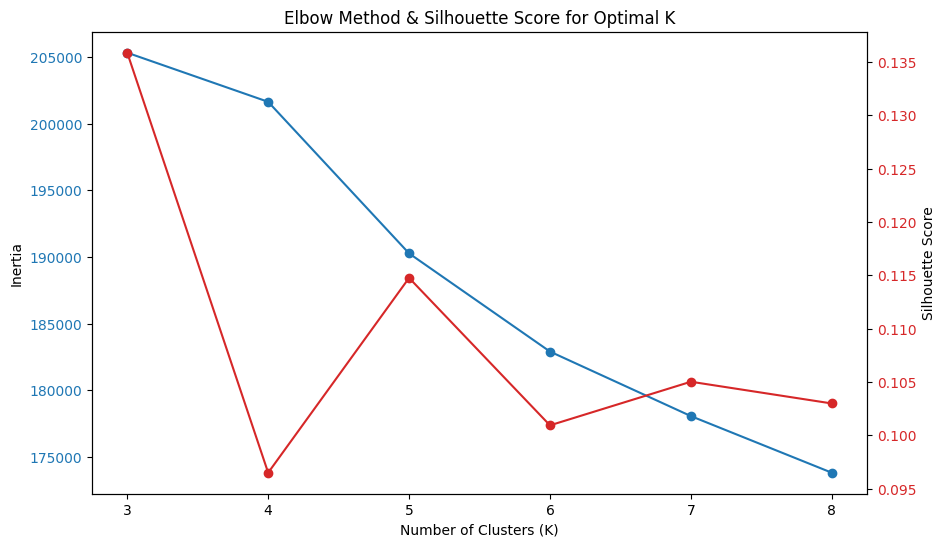

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

range_k = range(3, 9)

inertia = []
silhouette_avg = []


for k in range_k:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(df_scaled)

  inertia.append(kmeans.inertia_)

  score = silhouette_score(df_scaled, labels)
  silhouette_avg.append(score)

# Plot the elbow for k and slhouette
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Elbow Method (SSE)
color = "tab:blue"

ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.plot(range_k, inertia, marker='o', color=color, label='SSE (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)

# Plot Silhouette Score on the same X-axis but different Y-axis
ax2 = ax1.twinx()
color = "tab:red"

ax2.set_ylabel("Silhouette Score")
ax2.plot(range_k, silhouette_avg, marker='o', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method & Silhouette Score for Optimal K')
plt.show()

We see that the silhouette score peaks at number of cluster 5 with the inertia being minimized at from 3rd and 4th cluster. We decided to move ahead with 5 clusters

# Attaching the lables to the orignal one hot encoded dataset "X Engineered"

In [ ]:
X_engineered.columns

Index(['cat_unk__gender_Female', 'cat_unk__gender_Male',
       'cat_unk__gender_Non-Binary', 'cat_unk__gender_Unknown',
       'cat_unk__browsing_history_Education',
       'cat_unk__browsing_history_Entertainment',
       'cat_unk__browsing_history_News', 'cat_unk__browsing_history_Shopping',
       'cat_unk__browsing_history_Social Media',
       'cat_unk__browsing_history_Unknown', 'cat_mode__device_type_Desktop',
       'cat_mode__device_type_Mobile', 'cat_mode__device_type_Tablet',
       'cat_mode__ad_position_Bottom', 'cat_mode__ad_position_Side',
       'cat_mode__ad_position_Top', 'cat_mode__time_of_day_Afternoon',
       'cat_mode__time_of_day_Evening', 'cat_mode__time_of_day_Morning',
       'cat_mode__time_of_day_Night', 'num__age', 'num__missingindicator_age',
       'mobile_user', 'privacy_score', 'is_millenial'],
      dtype='object')

In [ ]:
from sklearn.cluster import KMeans

k_means_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = k_means_final.fit_predict(df_scaled)

# Attach the labels and click to Xengineered

X_engineered['click'] = data_1['click']
X_engineered['labels'] = cluster_labels

# 3. Calculate profiles
cluster_profiles = X_engineered.groupby('labels').agg({
    'num__age': 'mean',
    'privacy_score': 'mean',
    'click': 'mean',
    'cat_mode__device_type_Mobile': 'mean',  # Percentage of mobile users
    'cat_mode__ad_position_Top': 'mean'      # Percentage of top-position ads

}).rename(columns={'num__age': 'avg_age',
                   'click': 'avg_click_rate'})
print(cluster_profiles)


          avg_age  privacy_score  avg_click_rate  \
labels                                             
0       40.580882       0.000000        0.651195   
1       -1.000000       1.000000        0.660310   
2       19.335490       0.475970        0.688540   
3       40.776571       0.000000        0.622579   
4       20.247110       0.459538        0.611272   

        cat_mode__device_type_Mobile  cat_mode__ad_position_Top  
labels                                                           
0                           0.294118                   0.000000  
1                           0.197559                   0.202136  
2                           0.201479                   0.207024  
3                           0.152102                   0.418517  
4                           1.000000                   1.000000  


/tmp/ipykernel_5164/3288529499.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_profiles.index, y=cluster_profiles['avg_click_rate'], palette='RdYlGn')


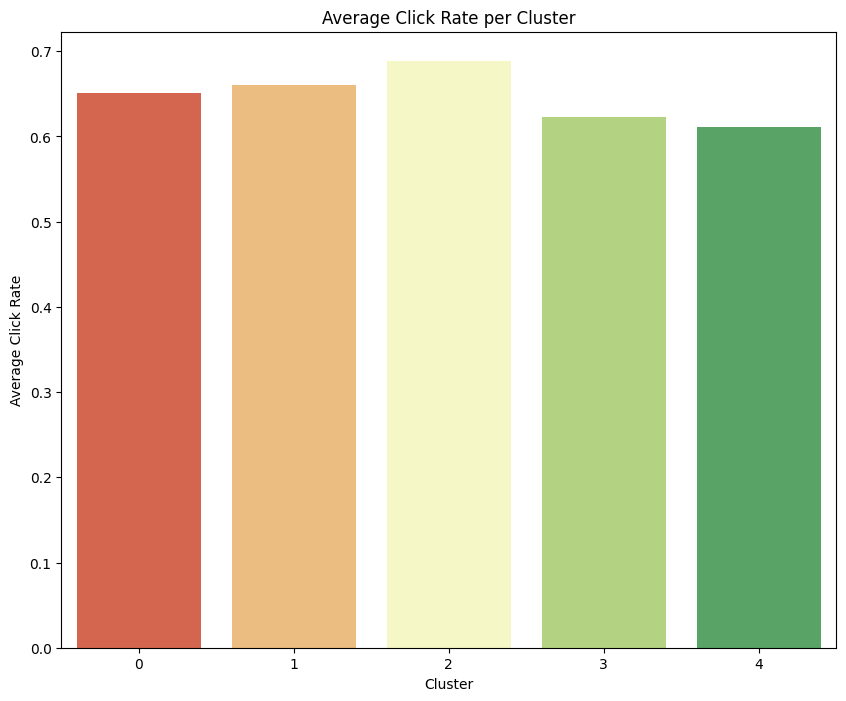

In [ ]:
# plot the cluster and click rates

plt.figure(figsize=(10, 8))
sns.barplot(x=cluster_profiles.index, y=cluster_profiles['avg_click_rate'], palette='RdYlGn')
plt.xlabel('Cluster')
plt.ylabel('Average Click Rate')
plt.title('Average Click Rate per Cluster')
plt.show()

Cluster 2 has the highest Avg Click Through Rate. We now run the S**tatistical Test: Chi-Square Test of Independence** to determine if the differences in click-through rates (CTR) between your clusters are statistically significant

# Statistical Test: Chi-Square Test of Independence

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Create a contingency table (Counts of clicks and non-clicks per cluster)
contingency_table = pd.crosstab(X_engineered['labels'], X_engineered['click'])

print(f"Contingency Table:\n{contingency_table}")

# Perform chi_square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

# 3. Interpret the result
alpha = 0.05
if p_value < alpha:
    print("\nReject the null hypothesis. There is a significant difference in click-through rates between clusters.")
else:
    print("\nFail to reject the null hypothesis. There is no significant difference in click-through rates between clusters.")

Contingency Table:
click      0     1
labels            
0        759  1417
1       1336  2597
2        337   745
3        799  1318
4        269   423

Chi-Square Statistic: 20.4747
P-value: 0.0004

Reject the null hypothesis. There is a significant difference in click-through rates between clusters.


The Chi-Square statistic of 20.47 confirms that the "Click" vs. "No Click" distribution is not uniform across your segments.

# Visualize Clusters using PCA

We use the force rednder fix that bypasses potential environment glitches (like overlapping figures) and explicitly handles the "stacked" data points by adding a tiny bit of "jitter."

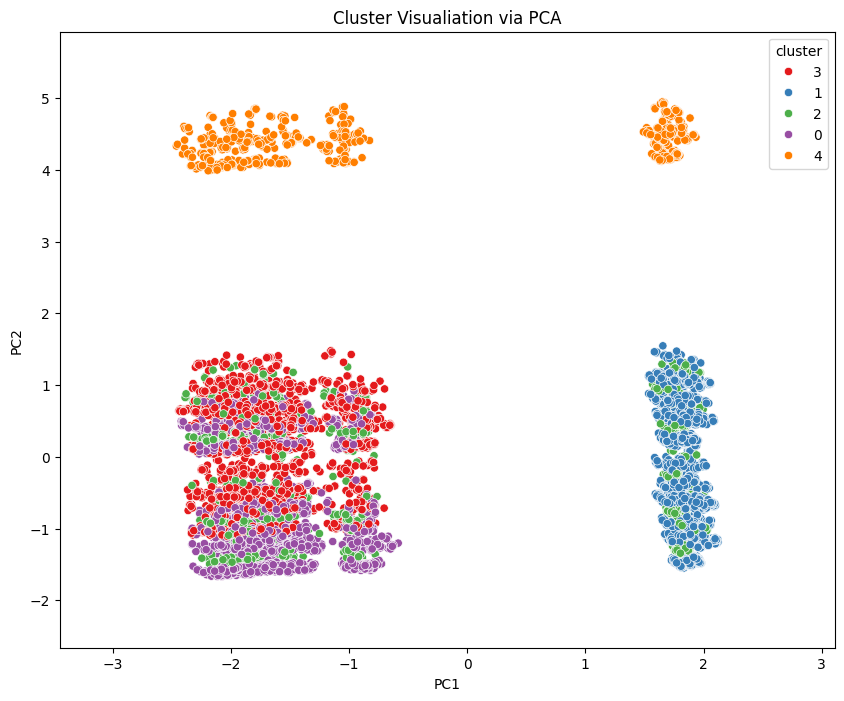

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure no NaNs exist in the scaled data (PCA will fail otherwise)
if df_scaled.isnull().values.any():
    print("Warning: NaNs found in df_scaled. Filling with 0 for PCA.")
    pca_input = df_scaled.fillna(0)
else:
    pca_input = df_scaled

# 2. Run PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(pca_input)

# 3. Explicitly create the DataFrame
# Fix: Rename columns of pca_results directly, as it's already a DataFrame.
df_pca = pca_results.rename(columns={'pca0': 'PC1', 'pca1': 'PC2'}) # Correctly rename 'pca0' to 'PC1' and 'pca1' to 'PC2'
df_pca['cluster'] = cluster_labels.astype(str)

plt.clf()
plt.close('all')

# Create a fresh figure
fig, ax = plt.subplots(figsize=(10, 8))

# Perform PCA
# JITTER: If points are overlapping perfectly, we add a tiny bit of noise
# so we can actually see the "clouds" of data

x_jitter = df_pca['PC1'] + np.random.normal(0, 0.01, size=len(df_pca))
y_jitter = df_pca['PC2'] + np.random.normal(0, 0.01, size=len(df_pca))

sns.scatterplot(x=x_jitter, y=y_jitter,
                hue=df_pca['cluster'], palette='Set1', ax=ax)
ax.set_ylim(df_pca['PC2'].min() - 1, df_pca['PC2'].max() + 1)
ax.set_xlim(df_pca['PC1'].min() - 1, df_pca['PC1'].max() + 1)

plt.title("Cluster Visualiation via PCA")
plt.show()

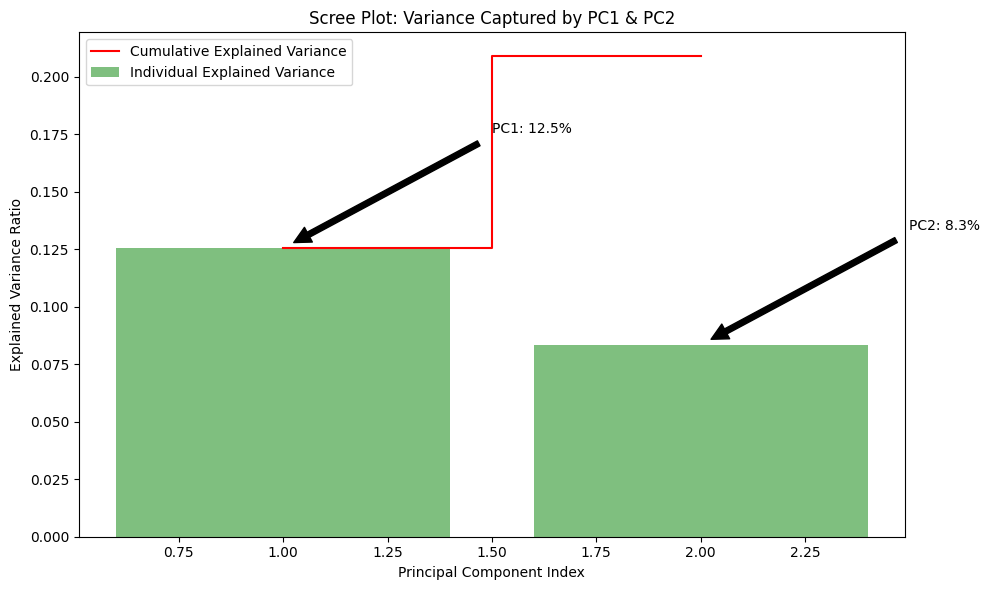

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate variance ratios from your PCA object
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Bar chart for individual variance
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center',
        label='Individual Explained Variance', color='g')

# Step plot for cumulative variance
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid',
         label='Cumulative Explained Variance', color='red')

# 3. Annotate PC1 and PC2 specifically
plt.annotate(f'PC1: {exp_var_pca[0]:.1%}', xy=(1, exp_var_pca[0]), xytext=(1.5, exp_var_pca[0]+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'PC2: {exp_var_pca[1]:.1%}', xy=(2, exp_var_pca[1]), xytext=(2.5, exp_var_pca[1]+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot: Variance Captured by PC1 & PC2')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
df_scaled.min()

,0
cat_unk__gender_Female,-0.473909
cat_unk__gender_Male,-0.470108
cat_unk__gender_Non-Binary,-0.446623
cat_unk__gender_Unknown,-0.940374
cat_unk__browsing_history_Education,-0.338678
cat_unk__browsing_history_Entertainment,-0.364890
cat_unk__browsing_history_News,-0.328871
cat_unk__browsing_history_Shopping,-0.330362
cat_unk__browsing_history_Social Media,-0.343246
cat_unk__browsing_history_Unknown,-0.957310


In [ ]:
# Check which original features contribute most to PC1 and PC2
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=pca_input.columns
)
print("The features that drove the PCA Components")
print(loadings.sort_values(by='PC1', ascending=False).head(5))

The features that drove the PCA Components
                                        PC1       PC2
num__missingindicator_age          0.555716  0.009840
privacy_score                      0.555716  0.009840
cat_unk__gender_Non-Binary         0.044345  0.049103
cat_unk__browsing_history_Unknown  0.030498 -0.049125
cat_mode__time_of_day_Evening      0.020377 -0.000375


# Cluster Profiling and Naming

In [ ]:
# Create cluster summary
cluster_summary = []

# find identity of each cluster
for i in range(5):
  # Get data for just this cluster
  this_cluster = X_engineered[X_engineered['labels'] == i]

  # Find the top 3 features where this clsuter is most different from the average
  diff = (this_cluster.mean() - X_engineered.mean().sort_values(ascending=False))
  top3 = diff.head(3).index.tolist()
  cluster_summary.append({
      'cluster': i,
      'CTR': f"{X_engineered[X_engineered['labels'] == i]['click'].mean():.2f}",
      'top_features': top3
  })
df_summary = pd.DataFrame(cluster_summary)
print(df_summary.head())

   cluster   CTR                                       top_features
0        0  0.65  [cat_mode__ad_position_Bottom, cat_mode__ad_po...
1        1  0.66  [cat_mode__ad_position_Bottom, cat_mode__ad_po...
2        2  0.69  [cat_mode__ad_position_Bottom, cat_mode__ad_po...
3        3  0.62  [cat_mode__ad_position_Bottom, cat_mode__ad_po...
4        4  0.61  [cat_mode__ad_position_Bottom, cat_mode__ad_po...


In [ ]:
print(df_summary['top_features'][0])
print(df_summary['top_features'][1])
print(df_summary['top_features'][2])

['cat_mode__ad_position_Bottom', 'cat_mode__ad_position_Side', 'cat_mode__ad_position_Top']
['cat_mode__ad_position_Bottom', 'cat_mode__ad_position_Side', 'cat_mode__ad_position_Top']
['cat_mode__ad_position_Bottom', 'cat_mode__ad_position_Side', 'cat_mode__ad_position_Top']


It seems like ad_position is very dominant feature driving all the clusters in ou KMeans. To fix this now we do Z-score or Relative Difference Profiling in which instead of looking at the highest mean we calculate how many standard deviations away a cluster's mean is from the overall dataset mean.

In [ ]:
X_engineered.columns

Index(['cat_unk__gender_Female', 'cat_unk__gender_Male',
       'cat_unk__gender_Non-Binary', 'cat_unk__gender_Unknown',
       'cat_unk__browsing_history_Education',
       'cat_unk__browsing_history_Entertainment',
       'cat_unk__browsing_history_News', 'cat_unk__browsing_history_Shopping',
       'cat_unk__browsing_history_Social Media',
       'cat_unk__browsing_history_Unknown', 'cat_mode__device_type_Desktop',
       'cat_mode__device_type_Mobile', 'cat_mode__device_type_Tablet',
       'cat_mode__ad_position_Bottom', 'cat_mode__ad_position_Side',
       'cat_mode__ad_position_Top', 'cat_mode__time_of_day_Afternoon',
       'cat_mode__time_of_day_Evening', 'cat_mode__time_of_day_Morning',
       'cat_mode__time_of_day_Night', 'num__age', 'num__missingindicator_age',
       'mobile_user', 'privacy_score', 'is_millenial', 'click', 'labels'],
      dtype='object')

In [ ]:
# List of columns to ignore during profiling
ignore_cols = ['cluster', 'labels', 'click', 'remainder__click',
               'num__missingindicator_age']

# Calculate the global mean and std EXCLUDING the labels
# This ensures we only look at actual features
global_mean = X_engineered.drop(columns=ignore_cols, errors='ignore').mean()
global_std = X_engineered.drop(columns=ignore_cols, errors='ignore').std()

relative_summary = []
for i in range(5):
  this_cluster_data = X_engineered[X_engineered['labels'] == i].drop(columns=ignore_cols, errors='ignore')
  this_cluster_mean = this_cluster_data.mean()

  # Calculate Z-score: (Cluster Mean - Global Mean) / Global Std
  # This shows what is UNIQUE to this cluster
  z_scores = (this_cluster_mean - global_mean) / global_std

  # top z_scores
  unique_z_traits = z_scores.sort_values(ascending=False).head(3).index.tolist()

  relative_summary.append({
      'cluster': i,
      'CTR': f"{X_engineered[X_engineered['labels']==i]['click'].mean():.2%}",
      'unique_defining_features': unique_z_traits
  })

df_relative_summary = pd.DataFrame(relative_summary)
print(df_relative_summary)

   cluster     CTR                           unique_defining_features
0        0  65.12%  [cat_mode__ad_position_Bottom, num__age, is_mi...
1        1  66.03%  [privacy_score, cat_unk__browsing_history_Unkn...
2        2  68.85%  [cat_unk__browsing_history_Entertainment, cat_...
3        3  62.26%  [num__age, cat_mode__ad_position_Side, is_mill...
4        4  61.13%  [mobile_user, cat_mode__ad_position_Top, cat_m...


In [ ]:
print(f"0: {df_relative_summary.iloc[0]}\n")
print(f"1: {df_relative_summary.iloc[1]}\n")
print(f"2: {df_relative_summary.iloc[2]}\n")
print(f"3: {df_relative_summary.iloc[3]}\n")
print(f"4: {df_relative_summary.iloc[4]}")

0: cluster                                                                     0
CTR                                                                    65.12%
unique_defining_features    [cat_mode__ad_position_Bottom, num__age, is_mi...
Name: 0, dtype: object

1: cluster                                                                     1
CTR                                                                    66.03%
unique_defining_features    [privacy_score, cat_unk__browsing_history_Unkn...
Name: 1, dtype: object

2: cluster                                                                     2
CTR                                                                    68.85%
unique_defining_features    [cat_unk__browsing_history_Entertainment, cat_...
Name: 2, dtype: object

3: cluster                                                                     3
CTR                                                                    62.26%
unique_defining_features    [num__age, cat_mode__ad_positi

In [ ]:
df_relative_summary['unique_defining_features'].iloc[0]

['cat_mode__ad_position_Bottom', 'num__age', 'is_millenial']

In [ ]:
df_relative_summary['unique_defining_features'].iloc[1]

['privacy_score',
 'cat_unk__browsing_history_Unknown',
 'cat_mode__ad_position_Bottom']

In [ ]:
df_relative_summary['unique_defining_features'].iloc[2]

['cat_unk__browsing_history_Entertainment',
 'cat_mode__device_type_Desktop',
 'is_millenial']

In [ ]:
df_relative_summary['unique_defining_features'].iloc[3]

['num__age', 'cat_mode__ad_position_Side', 'is_millenial']

In [ ]:
df_relative_summary['unique_defining_features'].iloc[4]

['mobile_user', 'cat_mode__ad_position_Top', 'cat_mode__device_type_Mobile']

# **Cluster Interpretation**


*   Cluster 0 (The "Standard" Millennial): These are likely millennials who are highly predictable—they browse normally and engage with the most common ad placement (Bottom).

*   Cluster 1 (The "Private" Bottom-Clicker): This is a very interesting find. Even though they hide their browsing history and age (High Privacy Score), their physical behavior on the page is consistent with Cluster 0—they still click on the Bottom ads. This suggests that ad placement often overrides privacy preferences when it comes to actual clicks.

*   Cluster 2 (The High-Value Desktop Millennial): The "Gold" segment. Desktop users who are millennials and looking at Entertainment content are the most receptive audience. The "Unknown" browsing history here likely means they are in "Incognito" or using privacy tools, but they are still highly active.


*   Cluster 3 (The Sidebar Millennial): These users are unique because they are the only ones paying attention to the Side ads. Since this is also a millennial group, it shows that even within the same age demographic, UI layout (Sidebar vs. Bottom) creates different sub-behaviors.

*   Cluster 4 (The Mobile Top-Skimmer): These are the mobile-only users who are clicking the Top ads (likely because those are the first things visible on a small screen), but they have the lowest CTR, suggesting "Top" ads on mobile might suffer from accidental clicks or "banner blindness."


# Deep Learning Clustering (Autoencoder + K-Means)
The Autoencoder learns a compressed representation of the data. Hint: The Latent Layer (Bottleneck) size of 8 neurons is critical. The model learns to reconstruct the input, forcing the bottleneck to capture only the most essential features of the user profile. Train the model until the reconstruction loss stabilizes.



In [ ]:
df_scaled.columns

Index(['cat_unk__gender_Female', 'cat_unk__gender_Male',
       'cat_unk__gender_Non-Binary', 'cat_unk__gender_Unknown',
       'cat_unk__browsing_history_Education',
       'cat_unk__browsing_history_Entertainment',
       'cat_unk__browsing_history_News', 'cat_unk__browsing_history_Shopping',
       'cat_unk__browsing_history_Social Media',
       'cat_unk__browsing_history_Unknown', 'cat_mode__device_type_Desktop',
       'cat_mode__device_type_Mobile', 'cat_mode__device_type_Tablet',
       'cat_mode__ad_position_Bottom', 'cat_mode__ad_position_Side',
       'cat_mode__ad_position_Top', 'cat_mode__time_of_day_Afternoon',
       'cat_mode__time_of_day_Evening', 'cat_mode__time_of_day_Morning',
       'cat_mode__time_of_day_Night', 'num__age', 'num__missingindicator_age',
       'mobile_user', 'privacy_score', 'is_millenial'],
      dtype='object')

We are using 'linear' activation function for the output layer because the non-linearity of the data is captured by the hidden layers (the relu layers in your encoder and decoder). Those layers allow the model to learn complex, "unfolding" relationships. Input data contains negative values (e.g., -1.2, -0.5) using StandardScaler so sigmoid is mathematically incapable of producing a negative number (it only outputs values between $0$ and $1$). 'Linear Activation function' can perfectly map to the negative and positive values of the scaled data

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Input

# The number of features in scaled data
input_dim = df_scaled.shape[1]

# Define the input layer for the autoencoder
input_layer = Input(shape=(input_dim,))

# Encoder for compressing the data
encoder_layers = models.Sequential([
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu')
])

# Decoder for reconstructing the data
decoder_layers = models.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(input_dim, activation='linear') # we use sigmoid because our data is scaled and linear in nature
])

# Connect the layers to form the autoencoder using the Functional API
encoded = encoder_layers(input_layer)
decoded = decoder_layers(encoded)

# Complete Autoencoder model definition
autoencoder = models.Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Training the target y is the input X
history_1 = autoencoder.fit(df_scaled, df_scaled,
                            epochs=50, batch_size=32,
                            validation_split=0.2,
                            verbose=1)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.8387 - val_loss: 0.6650
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5985 - val_loss: 0.5420
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5022 - val_loss: 0.4616
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4345 - val_loss: 0.4090
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3891 - val_loss: 0.3692
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3539 - val_loss: 0.3415
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3249 - val_loss: 0.3119
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2998 - val_loss: 0.2889
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2783 - val_loss: 0.2667
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2579 - val_loss: 0.2482
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2385 - val_loss: 0.2288
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

After training, use only the Encoder part of the model to transform the original dataset into the new 8-dimensional latent feature space.

In [ ]:
# 1. Create a sub-model that stops at the bottleneck
encoder_only = models.Model(inputs=autoencoder.input, outputs=encoded)

# 2. Transform your data into the 8-dimensional "Essential" space
X_latent = encoder_only.predict(df_scaled)

print(f"Original shape: {df_scaled.shape}")
print(f"Compressed latent shape: {X_latent.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Original shape: (10000, 25)
Compressed latent shape: (10000, 8)


# K-Means on Latent Space
Out of the 25 features we have extracted 8 "Super Features. We will now perform the final clustering on this "clean" latent space.


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

k_means_auto = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels_auto = k_means_auto.fit_predict(X_latent)

# Check new silhouette score
s_scores = silhouette_score(X_latent, cluster_labels_auto)
print(f"New silhouette score: {s_scores}")

New silhouette score: 0.2458798885345459


In [ ]:
x = np.mean(silhouette_avg)
np.round(x, 4)

np.float64(0.1093)

# Compare Machine Learning vs Deep Learning
Compare the Silhouette Score and Davies-Bouldin Index (DB Index) for both the ML-KMeans and DL-Autoencoder + K-Means models. A higher Silhouette Score (closer to 1) and a lower DB Index (closer to 0) indicate better, more compact, and distinct clusters.


# KMeans Cluster Profile Min Max

In [ ]:
kmeans_cluster_profiles = cluster_profiles.copy()

# Find the cluster (index) with the maximum 'avg_click_rate'
max_ctr_cluster_label = kmeans_cluster_profiles['avg_click_rate'].idxmax()
# Get the row corresponding to the max CTR cluster
max_ctr_cluster_info = kmeans_cluster_profiles.loc[max_ctr_cluster_label]

# Find the cluster (index) with the minimum 'avg_click_rate'
min_ctr_cluster_label = kmeans_cluster_profiles['avg_click_rate'].idxmin()
# Get the row corresponding to the min CTR cluster
min_ctr_cluster_info = kmeans_cluster_profiles.loc[min_ctr_cluster_label]

print(f"Max CTR rate for KMeans Cluster Profiles: Cluster {max_ctr_cluster_label} with CTR {max_ctr_cluster_info['avg_click_rate']:.4f}")
print(f"Min CTR rate for KMeans Cluster Profiles: Cluster {min_ctr_cluster_label} with CTR {min_ctr_cluster_info['avg_click_rate']:.4f}")

Max CTR rate for KMeans Cluster Profiles: Cluster 2 with CTR 0.6885
Min CTR rate for KMeans Cluster Profiles: Cluster 4 with CTR 0.6113


# Calculate DB Index & CTR for the Davies-Bouldin (DB) Approach

In [ ]:
from sklearn.metrics import davies_bouldin_score

db_ml = davies_bouldin_score(df_scaled, cluster_labels)
db_dl = davies_bouldin_score(X_latent, cluster_labels_auto)

print(f"Machine Learning DB Index: {db_ml:.4f}")
print(f"Deep Learning DB Index: {db_dl:.4f}")

# 2. Calculate CTR for the new DL Clusters
df_eval = X_engineered.copy()
df_eval['dl_cluster'] = cluster_labels_auto

dl_ctr = df_eval.groupby('dl_cluster')['click'].mean().sort_values(ascending=False)

print("\nDL Cluster CTRs:")
print(dl_ctr)

Machine Learning DB Index: 2.5718
Deep Learning DB Index: 1.4034

DL Cluster CTRs:
dl_cluster
3    0.673995
4    0.654628
0    0.652361
2    0.650553
1    0.595718
Name: click, dtype: float64


In [ ]:
ml_ctr = kmeans_cluster_profiles['avg_click_rate'].sort_values(ascending=False)
print("ML Cluster CTRS:")
print(ml_ctr)

ML Cluster CTRS:
labels
2    0.688540
1    0.660310
0    0.651195
3    0.622579
4    0.611272
Name: avg_click_rate, dtype: float64


In [ ]:
ml_dl_df = pd.DataFrame({'ML CTR %': np.round(ml_ctr*100, 4), 'DL CTR %': np.round(dl_ctr*100, 4),
                         'ML DB Index': np.round(db_ml, 4), 'DL DB Index': np.round(db_dl, 4),
                         'ML Silhouette Score': np.round(x, 4), 'DL Silhouette Score': np.round(s_scores, 4)
                         })
ml_dl_df

,ML CTR %,DL CTR %,ML DB Index,DL DB Index,ML Silhouette Score,DL Silhouette Score
0,65.1195,65.2361,2.5718,1.4034,0.1093,0.2459
1,66.0310,59.5718,2.5718,1.4034,0.1093,0.2459
2,68.8540,65.0553,2.5718,1.4034,0.1093,0.2459
3,62.2579,67.3995,2.5718,1.4034,0.1093,0.2459
4,61.1272,65.4628,2.5718,1.4034,0.1093,0.2459


In [ ]:
# List of columns to ignore during profiling
ignore_cols = ['cluster', 'labels', 'click', 'remainder__click',
               'num__missingindicator_age', 'dl_cluster'] # Added 'dl_cluster'

# Calculate the global mean and std EXCLUDING the labels
# This ensures we only look at actual features
global_mean = df_eval.drop(columns=ignore_cols, errors='ignore').mean()
global_std = df_eval.drop(columns=ignore_cols, errors='ignore').std()

relative_summary = []
for i in range(5):
  this_cluster_data = df_eval[df_eval['dl_cluster'] == i].drop(columns=ignore_cols, errors='ignore')
  this_cluster_mean = this_cluster_data.mean()

  # Calculate Z-score: (Cluster Mean - Global Mean) / Global Std
  # This shows what is UNIQUE to this cluster
  z_scores = (this_cluster_mean - global_mean) / global_std

  # top z_scores
  unique_z_traits = z_scores.sort_values(ascending=False).head(3).index.tolist()

  relative_summary.append({
      'cluster': i,
      'CTR': f"{df_eval[df_eval['dl_cluster']==i]['click'].mean():.2%}",
      'unique_defining_features': unique_z_traits
  })

ae_relative_summary = pd.DataFrame(relative_summary)
print(ae_relative_summary)

   cluster     CTR                           unique_defining_features
0        0  65.24%  [cat_unk__browsing_history_Shopping, cat_mode_...
1        1  59.57%  [cat_unk__browsing_history_News, mobile_user, ...
2        2  65.06%  [cat_unk__browsing_history_Education, cat_unk_...
3        3  67.40%  [privacy_score, cat_unk__browsing_history_Unkn...
4        4  65.46%  [num__age, cat_unk__browsing_history_Unknown, ...


In [ ]:
print(ae_relative_summary['unique_defining_features'].iloc[0])

['cat_unk__browsing_history_Shopping', 'cat_mode__device_type_Desktop', 'cat_unk__gender_Male']


In [ ]:
print(ae_relative_summary['unique_defining_features'].iloc[1])

['cat_unk__browsing_history_News', 'mobile_user', 'cat_mode__ad_position_Top']


In [ ]:
print(ae_relative_summary['unique_defining_features'].iloc[2])

['cat_unk__browsing_history_Education', 'cat_unk__browsing_history_Social Media', 'cat_mode__ad_position_Bottom']


In [ ]:
print(ae_relative_summary['unique_defining_features'].iloc[3])

['privacy_score', 'cat_unk__browsing_history_Unknown', 'cat_unk__browsing_history_Entertainment']


In [ ]:
print(ae_relative_summary['unique_defining_features'].iloc[4])

['num__age', 'cat_unk__browsing_history_Unknown', 'is_millenial']


# Caluclate the relative Lift for DL and ML CTR

The ```13%``` figure for Deep Learning is a calculation of relative lift (also known as the efficiency gain) for every dollar we move from the worst-performing segment to your best-performing one.

$$\text{Relative Lift} = \frac{\text{CTR}_{\text{Target}} - \text{CTR}_{\text{Source}}}{\text{CTR}_{\text{Source}}} \times 100$$

In [ ]:
dl_ctr_low = 0.5957
dl_ctr_high = 0.6740

lift = (dl_ctr_high - dl_ctr_low) / dl_ctr_low
print(f"DL Lift Calculation: ({dl_ctr_high} - {dl_ctr_low}) / {dl_ctr_low} = {lift:.4%}")

DL Lift Calculation: (0.674 - 0.5957) / 0.5957 = 13.1442%


In [ ]:
ml_ctr_low = 0.6113
ml_ctr_high = 0.6885

lift = (ml_ctr_high - ml_ctr_low) / ml_ctr_low
print(f"ML Lift Calculation: ({ml_ctr_low} - {ml_ctr_low}) / {ml_ctr_low} = {lift:.4%}")

ML Lift Calculation: (0.6113 - 0.6113) / 0.6113 = 12.6288%


# Interpretation and Recommendations

### Profiling the DL Clusters


*   Cluster 3: This has the highest CTR of ```67.40%``` driven by the millenials browsing on Desktop Devices with entertaining themselves in incognito mode given the browsing history is unknown.

*   Cluster 4: The active millenial mobile scroller represent the cluster driving a CTR of ```65.46%```.
*   Cluster 0: shows the male desktop shoppers with shopping as browsing history. They have the CTR of ```65.24%```.

*   CLuster 2: belongs to the social and education readers who tend to click the ads placed at the bottom of the page with a CTR of ```65.06%```.
*   CLuster 1: is the low segment cluster with CTR of ```59.57%``` suggesting the banner blindness or accidental clicks on the top ads by the mobile users.

# Final Recommendations

*   Low-Value Clusters: CLuster 1 has been identified as low value segment. We can reduce the heavy traffic on the mobile news application as the clicks were majorily identified as accidental. We can rather move that budget to cluster 3 that has demonstrated to be the most valualble of all 5 clusters.  


*   High-Value Clusters: Alongside increasing the budget for Cluster 3 we can show brand awareness ads that don't rely on personal data respecting the privacy for high engagement.


*   Strategic Improvement: For desktop users more detailed, text-rich creatives ads can be created for larger screens for entertainment. Large CTA (call to action) buttons "BUY NOW" & "50% DISCOUNT", "LIMITED OFFER", can be added to the ads. We can use "Related Content" style ads that look like a natural continuation of the article they just finished reading.



